# Exploratory Data Analysis

In this notebook, we will do some exploratory data analysis to understand the relationships between certain features and the target variable, and inter-feature relationships.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Data/full_data.csv")

In [3]:
df.head()

,Series,Surface,Round,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,5SMA
0,International,Clay,2nd Round,417,97,5.00,1170,28,1.14,0,18,1,0,1.000000
1,Masters,Hard,1st Round,440,97,3.50,1385,18,1.28,0,18,1,0,0.500000
2,Grand Slam,Hard,1st Round,431,97,2.50,825,43,1.50,1,18,1,1,0.333333
3,Grand Slam,Hard,2nd Round,431,97,3.50,1230,24,1.28,1,18,1,1,0.500000
4,Grand Slam,Hard,3rd Round,431,97,2.75,770,48,1.39,0,18,1,1,0.600000


## 1. Odds

We begin with checking the relationship between the odds of Djokovic winning and the match outcome.

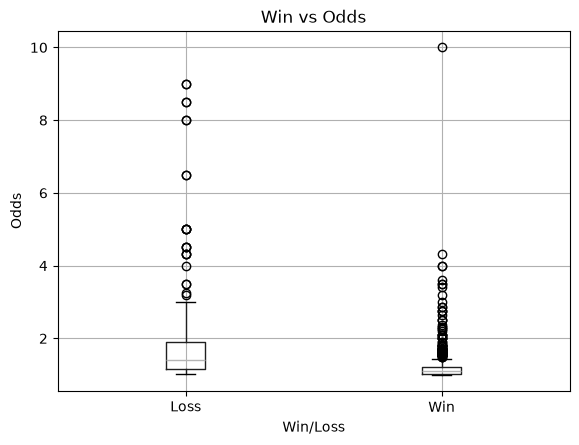

In [4]:
ax = df.boxplot(column=["dj_odds"], by="dj_win")

ax.figure.suptitle("")
ax.set_title("Win vs Odds")
ax.set_ylabel("Odds")
ax.set_xlabel("Win/Loss")
ax.set_xticklabels(["Loss", "Win"])

plt.show()

We can clearly see that there is some relationship between wins and odds. The interquartile range in the loss segment is larger, and there are clearly more losses from matches where Djokovic's odds were worse. The wins section is much more clustered together near the lower part of the odds range, however there is one outlier at odds of $10$ where Dkokovic managed to win the match. Now, let us plot histograms for the distribution of the odds for both wins and losses.

In [5]:
df_wins = df[df["dj_win"] == 1]
df_losses = df[df["dj_win"] == 0]

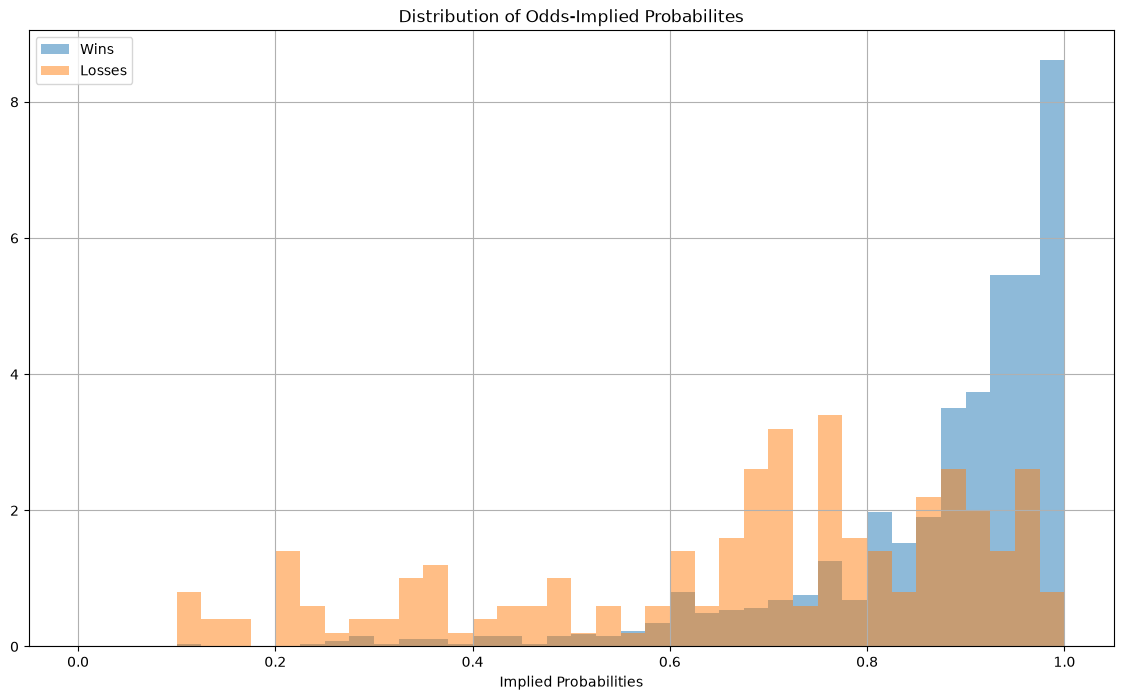

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

ax.hist(1 / df_wins["dj_odds"], bins=np.linspace(0, 1, 41), density=True,
        alpha=0.5, label="Wins")
ax.hist(1 / df_losses["dj_odds"], bins=np.linspace(0, 1, 41), density=True,
        alpha=0.5, label="Losses")

plt.legend()
plt.grid(True)
ax.set_title("Distribution of Odds-Implied Probabilites")
ax.set_xlabel("Implied Probabilities")
plt.show()


We can see that for the matches that Djokovic wins, his implied win probability is better/lower than those matches where he loses, since they are generally nearer to $1$ than for loss probabilities.

Now, we will evaluate the correctness of the bookmaker odds, by creating a decile plot illustrating the win rate for a a bin of matches, vs the implied win probability for each bin given by the bookmaker odds. To form the bins, we will order all matches by Djokovic odds first, and then take consecutive groups of $125$ matches. This will ensure the same number of datapoints for each comparison.

In [63]:
df_sorted_by_odds = df.sort_values(by="dj_odds").reset_index(drop=True)
values = {}

for i in range(10):
    start = 125 * i
    stop = 125 * (i + 1) if i != 9 else 1249

    rows = df_sorted_by_odds.iloc[start:stop]

    midpoint_probs = 1 / (rows["dj_odds"].median(axis=0))

    true_rate = rows["dj_win"].mean()

    values[midpoint_probs] = true_rate


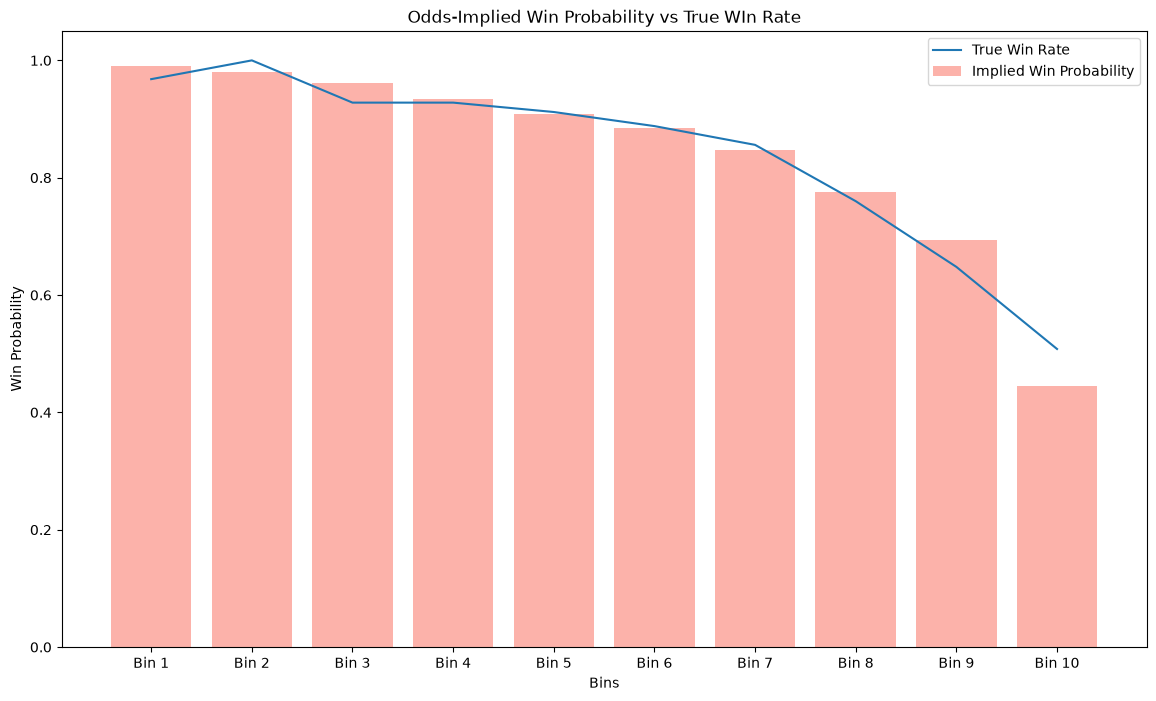

In [72]:
fig, ax = plt.subplots(figsize=(14, 8))
x = [f"Bin {i}" for i in np.arange(1, 11)]

ax.bar(x, height=values.keys(), alpha=0.6, color="salmon", label="Implied Win Probability")
ax.plot(x, values.values(), label="True Win Rate")

ax.set_xlabel("Bins")
ax.set_ylabel("Win Probability")
ax.set_title("Odds-Implied Win Probability vs True WIn Rate")
plt.legend()
plt.show()

We can see that the implied win probabilities generally track the true win rate for each bin relatively accurately. However, Djokovic's true win rate in the second bin was higher than in the first, and significantly greater than the odds-implied probability. In the third bin, the true win rate was somewhat lower than the implied probability. As the implied probability gets much lower (bin $9$ and bin $10$), there is a greater discrepancy between the true win rate and implied probability. This indicates that the probabilities are less accurate when Djokovic is deemed less likely to win.

## 2. Age

Usually, athletes' performance is strongly correlated with age. Most athletes have a rise up towards their prime, usually somewhere between ages $25-30$. This relationship between age and the target variable can be represented by a quadratic age feature. Let us now examine the number Djokovic's win rate for each year he has been active.

In [7]:
win_rates = {}

for i in df["age"].unique():
    df_age = df[df["age"] == i]
    win_rate = df_age["dj_win"].mean()
    win_rates[i] = win_rate

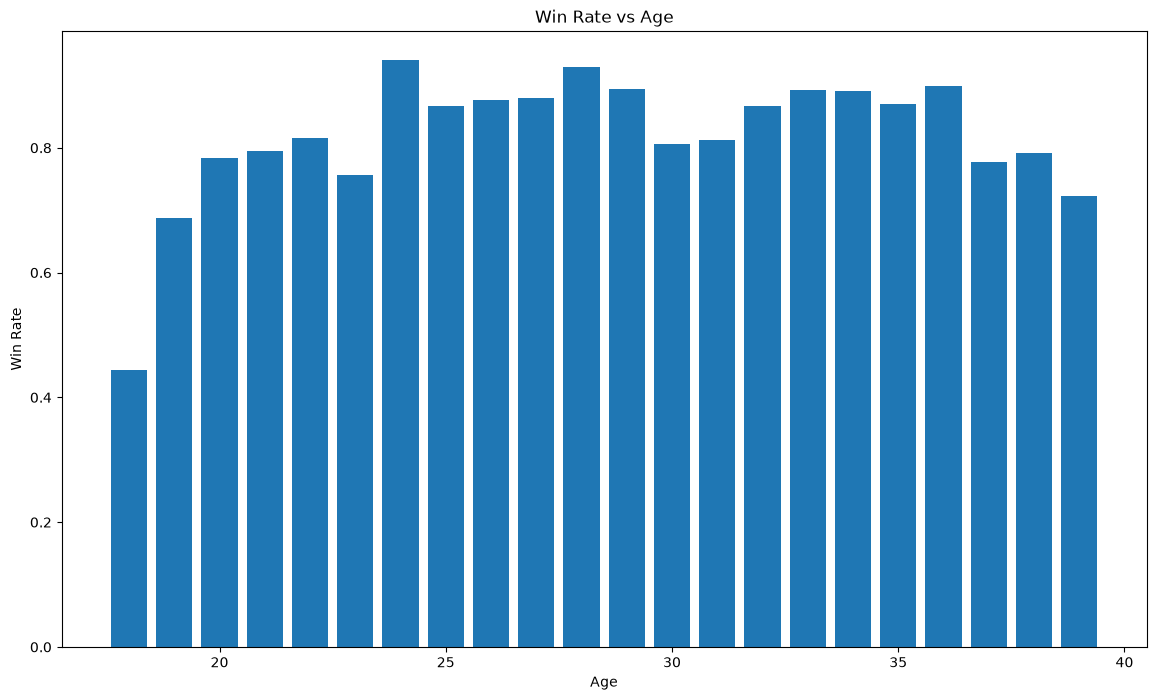

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.bar(win_rates.keys(), win_rates.values())
ax.set_xlabel("Age")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate vs Age")
plt.show()

As we can see, although there is a rise to a peak between $25-30$, Djokovic's win rate still stays quite high until there is a slight drop off ages $37-39$.

## 3. Opponent Rank

Another good indication of who will win the match is also the opponent's rank. We will now observe the relationship between this and the match outcome.

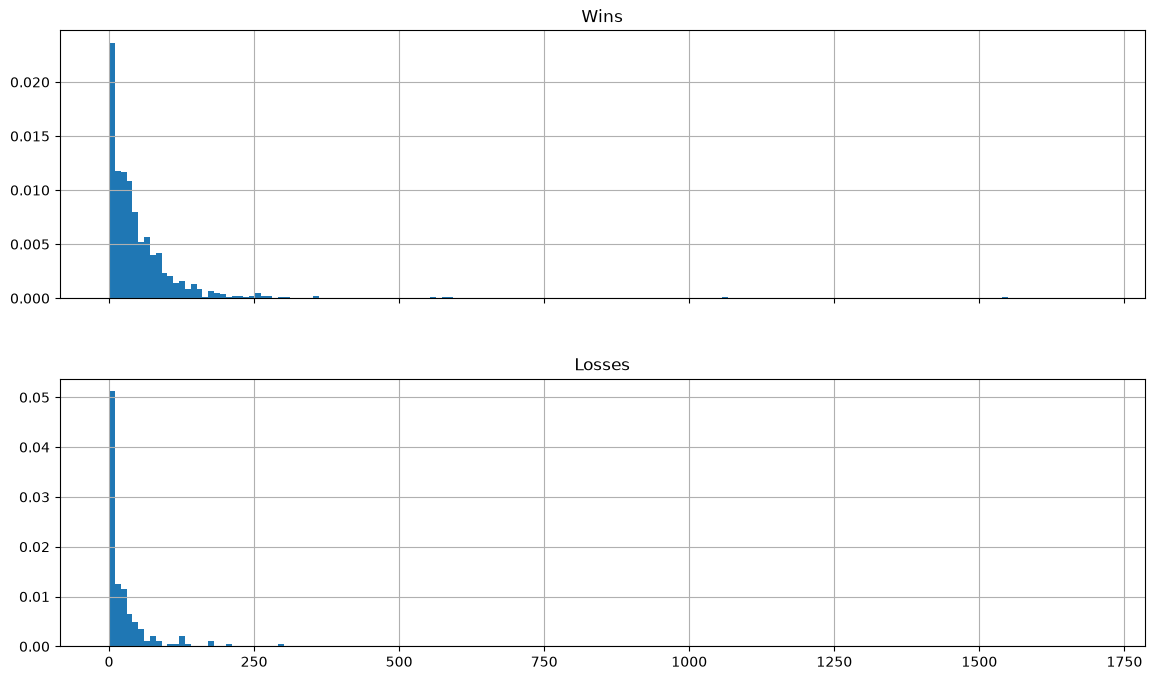

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

df_wins.hist(column="opp_rank", ax=ax[0], bins=np.linspace(0, 1700, 170), density=True)

df_losses.hist(column="opp_rank", ax=ax[1], bins=np.linspace(0, 1700, 170), density=True)

ax[0].set_title("Wins")
ax[1].set_title("Losses")

plt.show()

One can observe that, on average, the opponents that Djokovic loses to have better ranks than the players he wins against. This is intuitive.

## 4. Categorical Variables

We would now like to understand whether there is any relationship between the categorical variables Series, Surface, and Round against the win column.

In [10]:
def cat_summary(df, col, target="dj_win"):
    g = df.groupby(col)[target].agg(n="size", wins="sum", rate="mean")
    g["lift"] = g["rate"] - df[target].mean()
    g["se"] = np.sqrt(g["rate"] * (1 - g["rate"]) / g["n"])

    return g.sort_values("n", ascending=False)

In [27]:
series_order = [
    "International", "International Gold", "ATP250", "ATP500",
    "Masters", "Masters Cup", "Masters 1000", "Grand Slam"
    ]

g_series = cat_summary(df, "Series").reindex(series_order)
g_surface = cat_summary(df, "Surface")

round_order = [
    "1st Round", "2nd Round", "3rd Round", "4th Round",
    "Round Robin", "Quarterfinals", "Semifinals", "The Final",
]
g_round = cat_summary(df, "Round").reindex(round_order).dropna(subset=["n"])


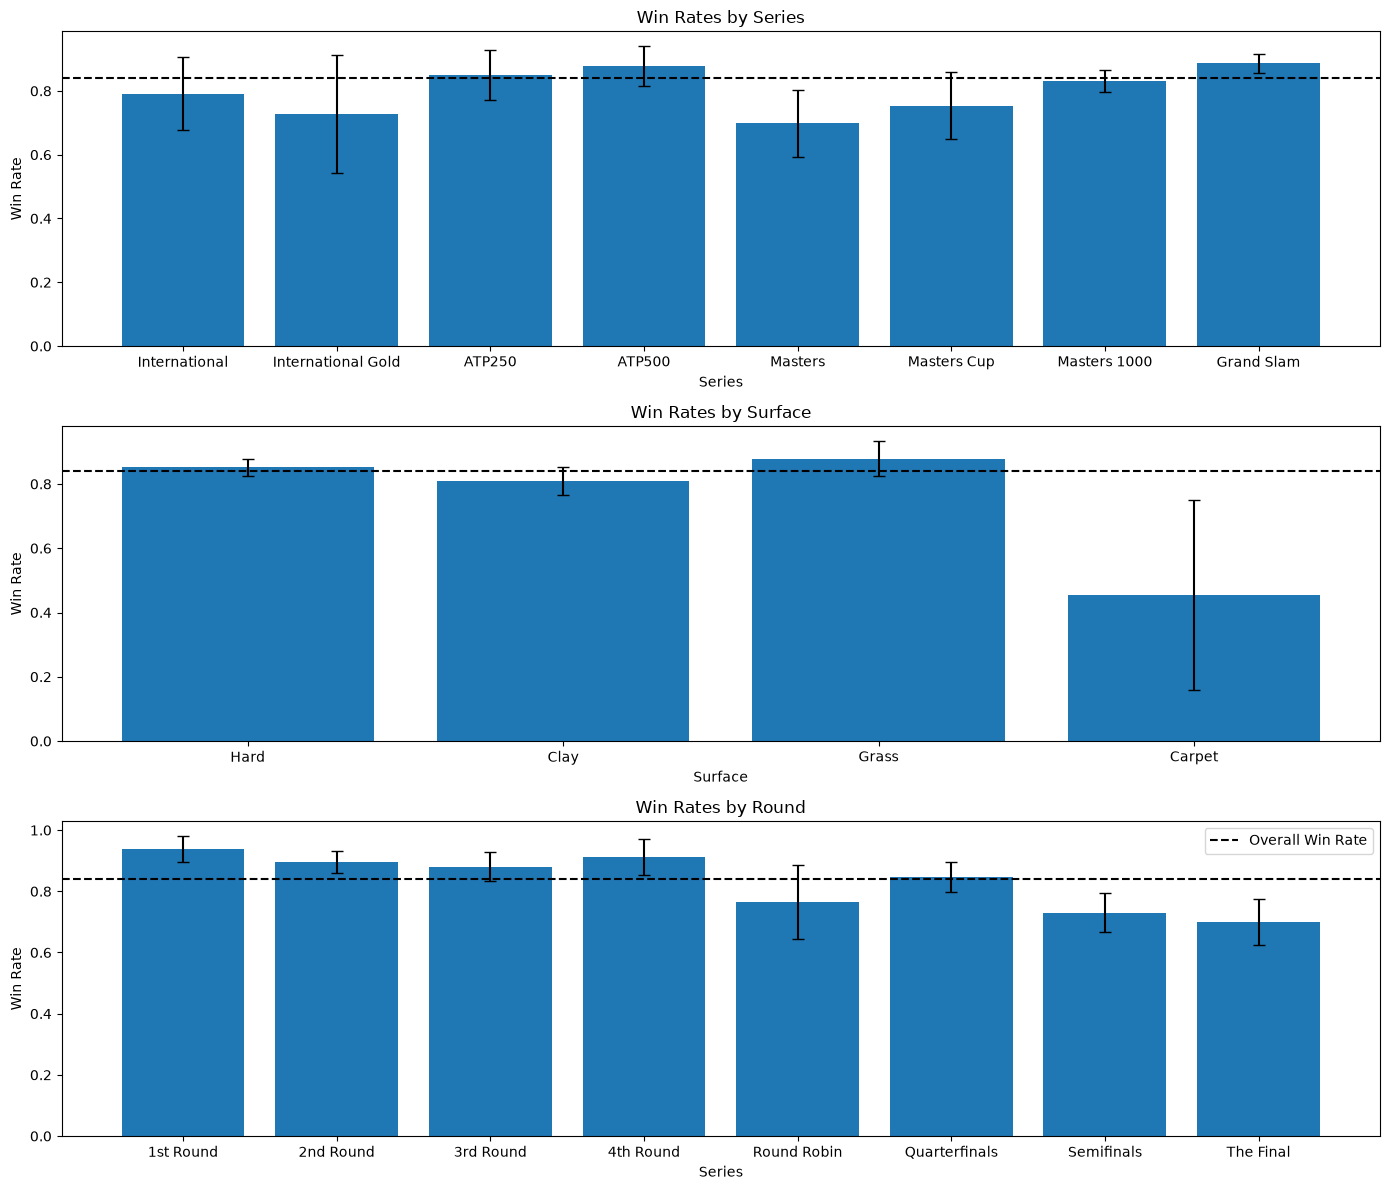

In [28]:
fig, ax = plt.subplots(3, 1, figsize=(14, 12))
ax[0].bar(g_series.index, g_series["rate"], yerr=1.96 * g_series["se"], capsize=4)
ax[0].axhline(df["dj_win"].mean(), ls="--", color="k", label="Overall Win Rate")
ax[0].set_title("Win Rates by Series")
ax[0].set_xlabel("Series")
ax[0].set_ylabel("Win Rate")

ax[1].bar(g_surface.index, g_surface["rate"], yerr=1.96 * g_surface["se"], capsize=4)
ax[1].axhline(df["dj_win"].mean(), ls="--", color="k", label="Overall Win Rate")
ax[1].set_title("Win Rates by Surface")
ax[1].set_xlabel("Surface")
ax[1].set_ylabel("Win Rate")

ax[2].bar(g_round.index, g_round["rate"], yerr=1.96 * g_round["se"], capsize=4)
ax[2].axhline(df["dj_win"].mean(), ls="--", color="k", label="Overall Win Rate")
ax[2].set_title("Win Rates by Round")
ax[2].set_xlabel("Series")
ax[2].set_ylabel("Win Rate")
plt.legend()
plt.tight_layout()
plt.show()

There are a couple of things to observe from this. Firstly, lets examine the Series findings. We can see that Djokovic performs the worst at Masters tournaments, by a relatively noticeable margin, and the top of the confidence interval not reaching the overall win rate. He also performs better in Grand Slams than in most other tournaments, with a small confidence interval indicating a large amount of evidence (many datapoints decreasing the standard error), due to him playing many Grand Slams.

For the Surface feature, he has similar win rates on Hard, Clay and Grass surfaces, but with a noticeably low win rate on Carpet.

In [32]:
df_carpet = df[df["Surface"] == "Carpet"]
print("Number of matches played on carpet:", len(df_carpet))

Number of matches played on carpet: 11


We see above that he has played very little matches on carpet, so we do not take this to be a significant finding, since there could very well be a small sample bias here.

For the Rounds findings, we can see that the win rate becomes lower as the tournament round becomes deeper. However, this is most probably due to the fact that Djokovic plays against better opponents as he progresses in the tournemant, not purely due to the specific round itself.

## 5. Numeric Variable Correlations

Let us now examine the collinearity of numeric columns. We expect that column pairs such as opponent odds and opponent rank will have some shared explanatory power.

In [13]:
df_numeric = df[["dj_pts", "dj_rank", "dj_odds", "opp_pts", "opp_rank", "opp_odds", "age"]]

<Axes: >

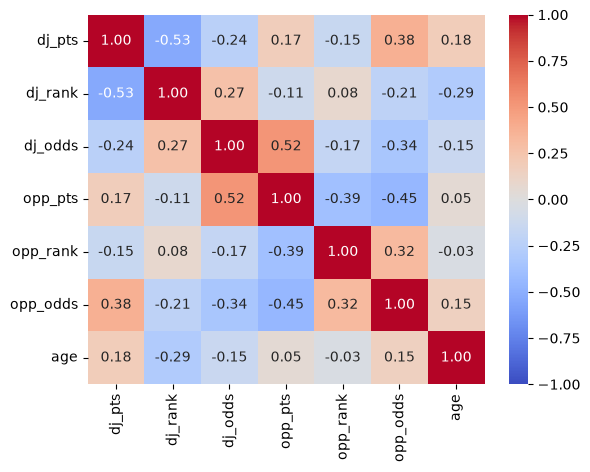

In [14]:
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1)

Clearly, some collinearity exists between some of the variables, for example Djokovic's odds and the opponent's points have a correlation of $0.52$, and opponent's odds and points have a correlation of $-0.34$.